In [1]:
import numpy as np
from pylab import *
from craco.cardcap import CardcapFile
from astropy.io import fits
from craft.craftcor import MiriadGainSolutions
import glob
from craco.search_pipeline import location2pix, get_grid_lut_from_plan, grid_candidates,wait_for_starts,waitall,print_candidates
from craco.search_pipeline import NBINARY_POINT_FDMTIN 
import craco
import craco.search_pipeline
from craco.pyxrtutil import *
import craft.craco_plan

from craft import uvfits

from craft.craco_plan import PipelinePlan
from craft.craco import printstats,bl2ant
import logging
import time

%matplotlib notebook
%load_ext autoreload
%autoreload 2


In [2]:
cd /data/craco/ban115/craco-python/notebooks/data/SB43128/run3


/data/craco/ban115/craco-python/notebooks/data/SB43128/run3


In [3]:
ls

1934_b07_c01+f1.fits  autos_ak09.fil
1934_b07_c01+f2.fits  autos_ak10.fil
1934_b07_c01+f3.fits  autos_ak11.fil
1934_b07_c01+f4.fits  autos_ak12.fil
1934_b07_c01+f5.fits  autos_ak13.fil
1934_b07_c01+f6.fits  autos_ak14.fil
1934_b07_c02+f1.fits  autos_ak15.fil
1934_b07_c02+f2.fits  autos_ak16.fil
1934_b07_c02+f3.fits  autos_ak17.fil
1934_b07_c02+f4.fits  autos_ak18.fil
1934_b07_c02+f5.fits  autos_ak19.fil
1934_b07_c02+f6.fits  autos_ak20.fil
1934_b07_c03+f1.fits  autos_ak21.fil
1934_b07_c03+f2.fits  autos_ak22.fil
1934_b07_c03+f3.fits  autos_ak23.fil
1934_b07_c03+f4.fits  autos_ak24.fil
1934_b07_c03+f5.fits  autos_ak25.fil
1934_b07_c03+f6.fits  autos_ak26.fil
1934_b07_c04+f1.fits  autos_ak27.fil
1934_b07_c04+f2.fits  autos_ak28.fil
1934_b07_c04+f3.fits  autos_ak29.fil
1934_b07_c04+f4.fits  autos_ak30.fil
1934_b07_c04+f5.fits  bandpass.amp.png
1934_b07_c04+f6.fits  bandpass.amp.png_2
1934_b07_c05+f1.fits  bandpass.imag.png
1934_b07_c05+f2.fits  bandpass.imag.png_2
1934_b07_c05+f3.fits  ba

In [49]:
miriadsol = MiriadGainSolutions('run3.mir')

Using MIRIAD bandpass solutions


/data/craco/ban115/craft-github/src/craft/craftcor.py:643: RuntimeWarning: divide by zero encountered in true_divide
  g = 1/np.conj(g)
/data/craco/ban115/craft-github/src/craft/craftcor.py:643: RuntimeWarning: invalid value encountered in true_divide
  g = 1/np.conj(g)


<IPython.core.display.Javascript object>


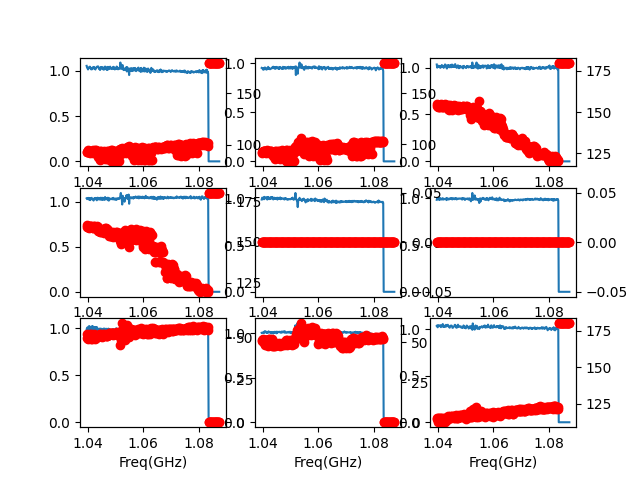

In [50]:
miriadsol.plot()

In [6]:
ls -lrth /data/craco/ban115/builds

total 381M
-rw-rw-r-- 1 ban115 ban115 77M Dec 13  2021 binary_container_7630dd1f.xclbin
-rw-rw-r-- 1 ban115 ban115 76M Dec 15  2021 binary_container_01482863.xclbin
-rw-rw-r-- 1 ban115 ban115 76M Feb 21  2022 binary_container_1_10688715.xclbin
-rw-rw-r-- 1 ban115 ban115 77M May 10 05:17 binary_container_28db073f.xclbin
-rw-rw-r-- 1 ban115 ban115 77M Jun 29 11:28 binary_container_fe3fef0d.xclbin


In [7]:
fits='SB43128_run3.uvfits'
#its='/data/craco/ban115/test_data/frb_d0_t0_a1_sninf_lm00/frb_d0_t0_a1_sninf_lm00.fits'


In [8]:
!ls -lh SB43128_run3.uvfits

-rw-rw-r-- 1 ban115 ban115 7.6G Aug  2 19:40 SB43128_run3.uvfits


In [9]:
values = craco.search_pipeline.get_parser().parse_args([])
print(values)

Namespace(boxcar_weight='sum', cand_file='candidates.txt', cell=None, device=0, dump_boxcar_hist_buf=None, dump_candidates=None, dump_fdmt_hist_buf=None, dump_mainbufs=None, dump_uvdata=None, fdmt_scale=1.0, fft_scale=10.0, fft_shift1=0, fft_shift2=0, injection_file=None, input_scale=1.0, max_ndm=1024, nblocks=None, nbox=8, ncin=32, ndm=512, ndout=186, npix=256, nt=256, nuvmax=8192, nuvwide=8, os='2.1,2.1', run_fdmt=True, run_image=True, show=False, show_candidate_grid=None, threshold=10.0, uv='frb_d0_lm0_nt16_nant24.fits', verbose=False, wait=False, xclbin='binary_container_1.xclbin.golden')


In [10]:
f = uvfits.open(fits)
f.set_flagants([23])
plan = PipelinePlan(f, "--ndm 2")

parsing values --ndm 2


/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=259.0 1-3 uvpix=(0, 254)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=260.0 1-4 uvpix=(2, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=522.0 2-10 uvpix=(15, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=0 or V=0 blid=522.0 2-10 uvpix=(16, 0)
  warnings.warn(f'Cannot grid things on U=0 or V=0 blid={blid} {a1}-{a2} uvpix={uvpix}')
/data/craco/ban115/craft-github/src/craft/craco_plan.py:138: UserWarning: Cannot grid things on U=

Upper registers [(2, 1), (3, 1), (14, 1), (15, 1), (166, 1), (167, 1), (168, 1), (169, 1), (170, 1), (236, 1), (237, 1), (241, 1), (243, 1), (248, 1), (249, 1), (255, 1), (33, 2), (34, 2), (35, 2), (46, 2), (51, 2), (52, 2), (53, 2), (54, 2), (206, 2), (207, 2), (208, 2), (209, 2), (224, 2), (225, 2), (226, 2), (235, 2)]
Lower registers [(1, 2), (2, 3), (2, 4), (1, 5), (4, 5), (4, 7), (5, 8), (6, 8), (5, 9), (7, 9), (8, 9), (4, 10), (6, 10), (8, 10), (1, 11), (5, 11), (6, 11), (8, 11), (9, 11), (1, 12), (5, 12), (7, 12), (7, 13), (12, 14), (13, 14), (12, 15), (13, 15), (7, 16), (14, 16), (15, 16), (7, 17), (15, 17)]


In [11]:
f.hdulist[3].data[0]


(1, 'B1934-638_beam0', 0, '', 0.0, 0.0, 0.0, 0.0, 0.0, 48.00000000000152, 294.8542750091011, -63.71266663279821, 2000.0, 294.8542750091011, -63.71266663279821, 0.0, 0.0, 0.0, 0.0)

In [12]:
f.hdulist[3].columns

ColDefs(
    name = 'ID. NO.'; format = '1J'
    name = 'SOURCE'; format = '50A'; unit = 'METERS'
    name = 'QUAL'; format = '1J'
    name = 'CALCODE'; format = '4A'
    name = 'IFLUX'; format = '1E'; unit = 'JY'
    name = 'QFLUX'; format = '1E'; unit = 'JY'
    name = 'UFLUX'; format = '1E'; unit = 'JY'
    name = 'VFLUX'; format = '1E'; unit = 'JY'
    name = 'FREQOFF'; format = '1D'
    name = 'BANDWIDTH'; format = '1D'; unit = 'HZ'
    name = 'RAEPO'; format = '1D'; unit = 'DEGREES'
    name = 'DECEPO'; format = '1D'; unit = 'YEARS'
    name = 'EPOCH'; format = '1D'; unit = 'DEGREES'
    name = 'RAAPP'; format = '1D'; unit = 'DEGREES'
    name = 'DECAPP'; format = '1D'; unit = 'DEGREES'
    name = 'LSRVEL'; format = '1D'; unit = 'M/SEC'
    name = 'RESTFREQ'; format = '1D'; unit = 'HZ'
    name = 'PMRA'; format = '1D'; unit = 'DEG/DAY'
    name = 'PMDEC'; format = '1D'; unit = 'DEG/DAY'
)

In [13]:
try:
    f.hdulist[0].data[0]['_DATE']
except KeyError:
    print('no _date')


no _date


In [14]:
from astropy.time import Time
Time(f.hdulist[0].data[0]['DATE'], format='jd', scale='utc').isot


'2022-08-02T09:07:02.478'

In [15]:
bl = f.baselines

<IPython.core.display.Javascript object>


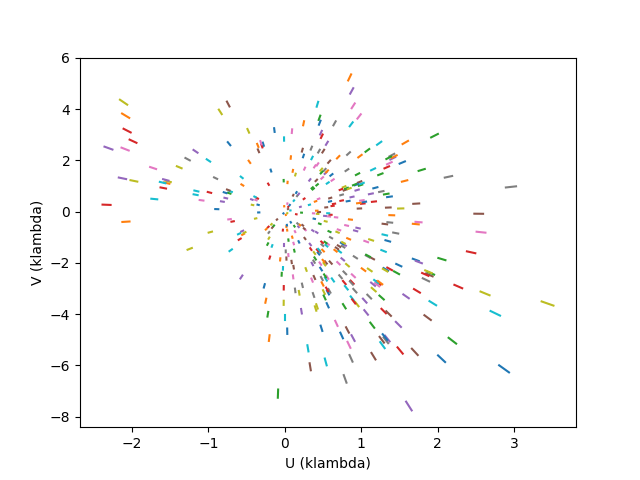

In [16]:
figure()
f.plot_baselines()

In [17]:
tb = next(f.time_blocks(2048))

In [18]:
d = craft.craco.bl2array(tb)

In [19]:
from craco import plotbp


In [20]:
binfile = '/data/craco/gup037/Calib_data/SB43128/SB43128_run3.aver.4pol.bin'
bp = plotbp.Bandpass.load(binfile)

Read bandpass: 1 solutions, 36 antennas, 288 channels, 4 polarisations


/data/craco/ban115/craco-python/src/craco/plotbp.py:70: RuntimeWarning: divide by zero encountered in true_divide
  self.bandpass = np.sqrt(2.0) / self.bandpass
/data/craco/ban115/craco-python/src/craco/plotbp.py:70: RuntimeWarning: invalid value encountered in true_divide
  self.bandpass = np.sqrt(2.0) / self.bandpass


<IPython.core.display.Javascript object>


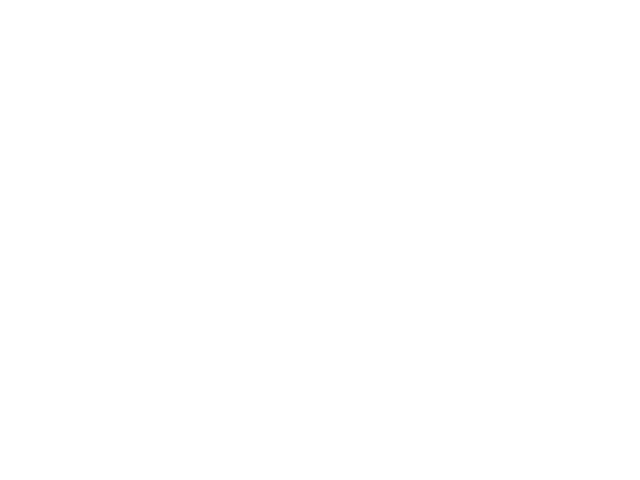

<IPython.core.display.Javascript object>


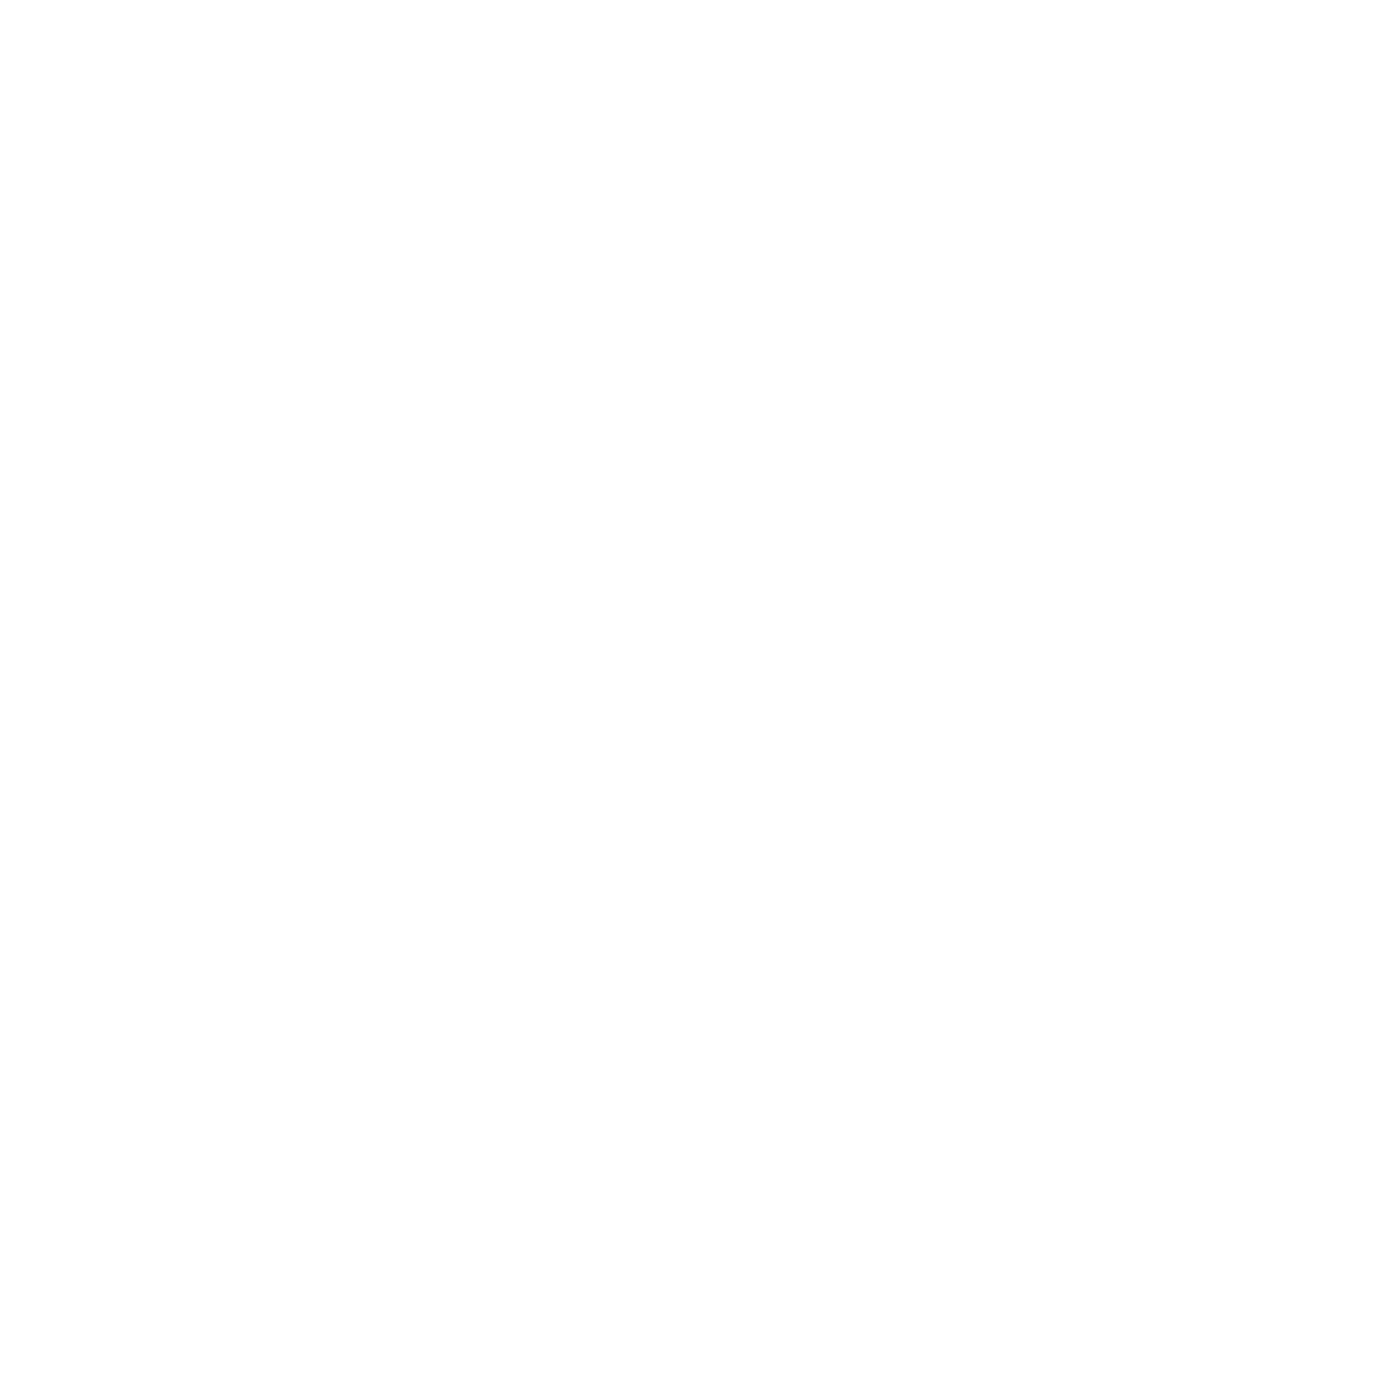

In [21]:
figure()
bp.plotGains(0, out_file='test.png')

In [71]:
soln = bp.bandpass[0]

In [72]:
soln.shape

(36, 288, 4)

In [73]:
soln.dtype

dtype('complex128')

In [74]:
d.shape

(406, 288, 2, 2048)

<IPython.core.display.Javascript object>


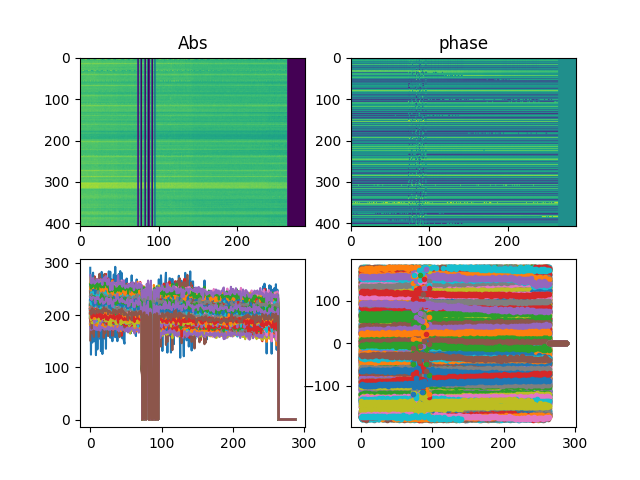

In [75]:
def pltcomplex(d):
    fig,ax = subplots(2,2)
    ax = ax.flatten()
    ax[0].imshow(np.abs(d), aspect='auto')
    ax[1].imshow(np.angle(d), aspect='auto')
    ax[1].set_title('phase')
    ax[0].set_title('Abs')
    ax[2].plot(np.abs(d).T)
    ax[3].plot(np.degrees(np.angle(d)).T,'.')
    return fig,ax
    
pltcomplex(d[:,:,0,:].mean(axis=2));

In [78]:
soln.shape

(36, 288, 4)

<IPython.core.display.Javascript object>


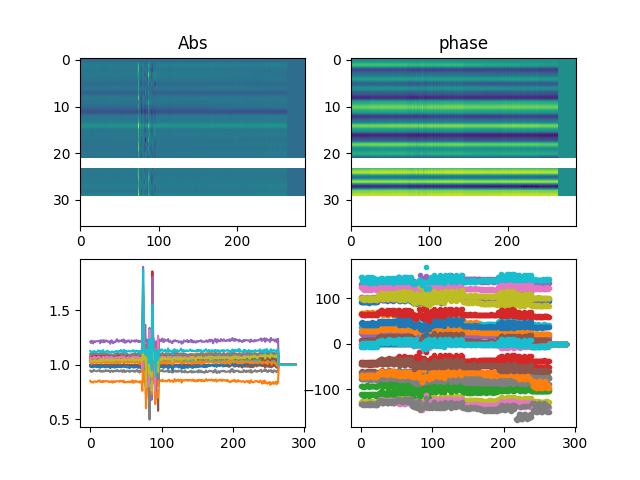

In [79]:
pltcomplex(soln[:,:,3]);

In [80]:
len(plan.baseline_order)

406

In [85]:
def gain2solarray(plan, soln):

    npol = 2
    solnarray = np.zeros((plan.nbl, plan.nf, 2), np.complex64)
    for ibl, blid in enumerate(plan.baseline_order):
        a1,a2 = bl2ant(blid)
        s1 = soln[a1-1,:,:]
        s2 = soln[a2-1,:,:]
        p = s1*np.conj(s2)
        solnarray[ibl,:,0] = p[...,0]
        solnarray[ibl,:,1] = p[...,1]

    solnarray = 1/solnarray

    return solnarray

solnarray = gain2solarray(plan, soln[...,[0,3]])
    

<IPython.core.display.Javascript object>


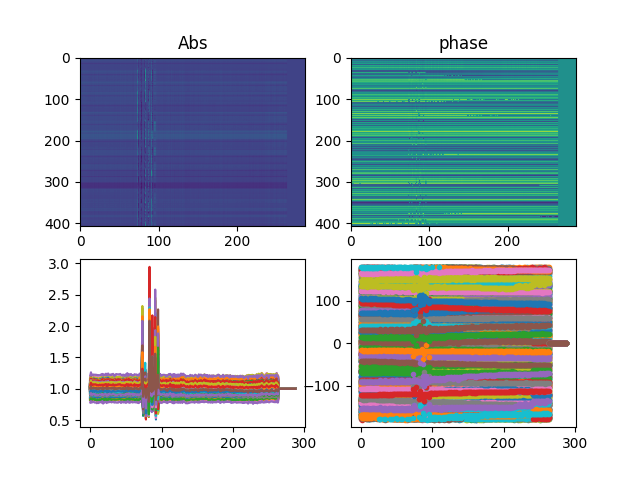

In [86]:
pltcomplex(solnarray[...,0]);

<IPython.core.display.Javascript object>


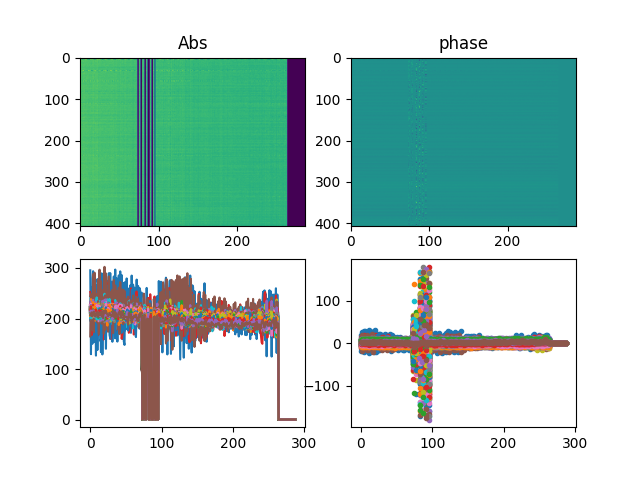

In [87]:
dtime = d.mean(axis=3)
pltcomplex(dtime[...,0]*solnarray[...,0]);

<IPython.core.display.Javascript object>


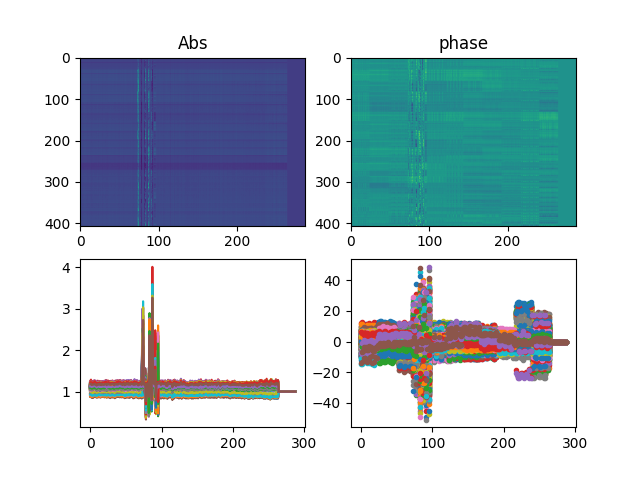

(<Figure size 640x480 with 4 Axes>,
 array([<AxesSubplot:title={'center':'Abs'}>,
        <AxesSubplot:title={'center':'phase'}>, <AxesSubplot:>,
        <AxesSubplot:>], dtype=object))

In [88]:
pltcomplex(solnarray[...,0] / solnarray[...,1])

In [89]:
correcti = (dtime*solnarray).mean(axis=2)
pseudoi = dtime.mean(axis=2)*solnarray.mean(axis=2)

<IPython.core.display.Javascript object>


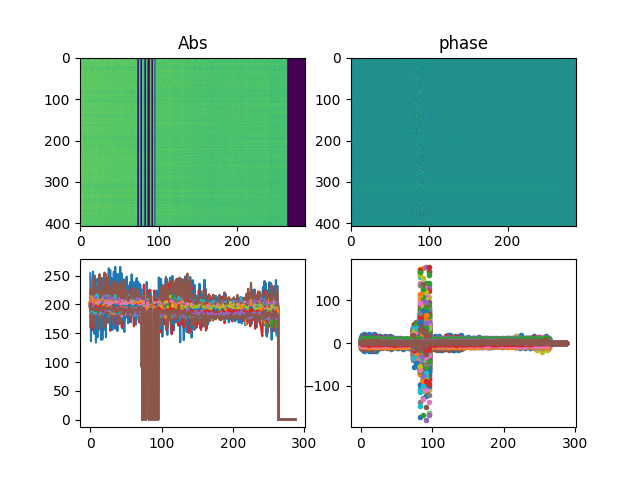

(<Figure size 640x480 with 4 Axes>,
 array([<AxesSubplot:title={'center':'Abs'}>,
        <AxesSubplot:title={'center':'phase'}>, <AxesSubplot:>,
        <AxesSubplot:>], dtype=object))

In [90]:
pltcomplex(correcti)

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


<IPython.core.display.Javascript object>


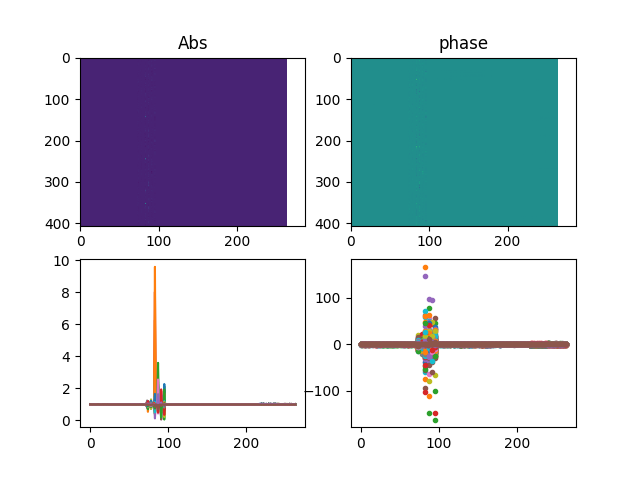

(<Figure size 640x480 with 4 Axes>,
 array([<AxesSubplot:title={'center':'Abs'}>,
        <AxesSubplot:title={'center':'phase'}>, <AxesSubplot:>,
        <AxesSubplot:>], dtype=object))

In [92]:
pltcomplex(correcti / pseudoi)

In [97]:
miriad_bp = miriadsol.bp_real + 1j*miriadsol.bp_imag

In [98]:
miriad_g = miriadsol.g_real + 1j*miriadsol.g_imag

In [99]:
miriad_gbp = (miriad_bp*miriad_g)
miriad_gbp.shape = (-1, 36, 2)
miriad_gbp = np.transpose(miriad_gbp, [1,0,2])

<IPython.core.display.Javascript object>


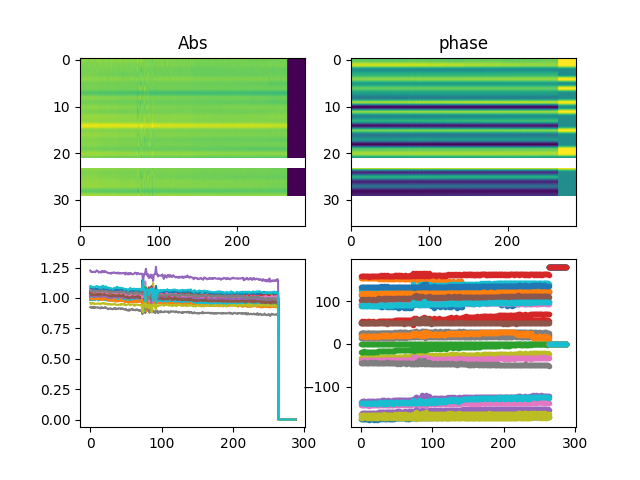

In [100]:
pltcomplex(miriad_gbp[...,0]);

In [101]:
miriad_solarray = gain2solarray(plan, miriad_gbp)

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: divide by zero encountered in true_divide
  del sys.path[0]
/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/ipykernel_launcher.py:13: RuntimeWarning: invalid value encountered in true_divide
  del sys.path[0]


/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in multiply
  """Entry point for launching an IPython kernel.


<IPython.core.display.Javascript object>


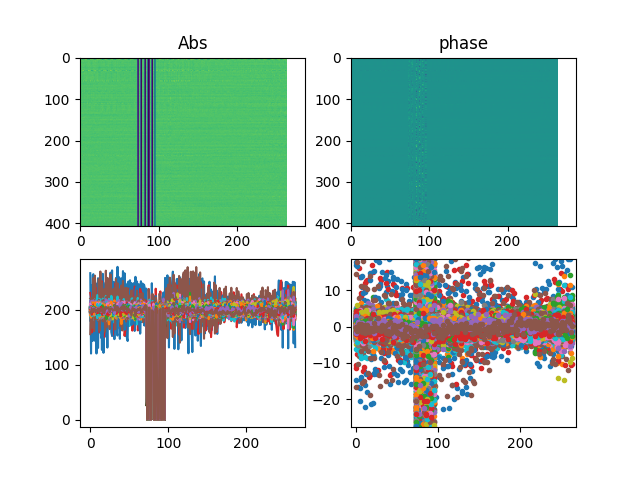

In [103]:
pltcomplex(dtime[...,0]*miriad_solarray[...,0]);


<IPython.core.display.Javascript object>


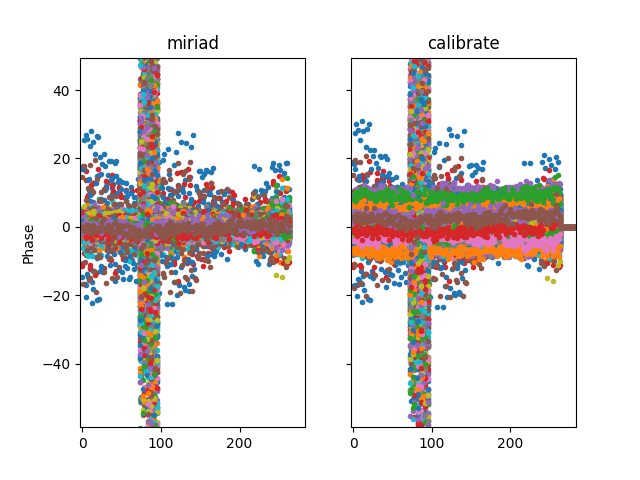

/data/craco/ban115/craco-python/venv/lib/python3.6/site-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in multiply
  


Text(0, 0.5, 'Phase')

In [119]:
fig,ax = subplots(1,2,sharex=True,sharey=True)
ax[0].plot(np.angle(dtime[...,0]*miriad_solarray[...,0],deg=True).T,'.');
ax[1].plot(np.angle(dtime[...,0]*solnarray[...,0],deg=True).T,'.');
ax[0].set_title('miriad')
ax[1].set_title('calibrate')
ax[0].set_ylabel('Phase')


In [110]:
np.angle?